# Biomedical Knowledge Graph Dataset Validation
This notebook performs exploratory validation and quality checks on the ADKG and MDKG biomedical relation extraction datasets before model training.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

## Library Imports
The following libraries are imported for dataset loading, visualization, and validation analysis.

In [2]:
with open("../data/ADKG.json") as f:
    adkg = json.load(f)

with open("../data/MDKG.json") as f:
    mdkg = json.load(f)

print("ADKG splits:", adkg.keys())
print("MDKG splits:", mdkg.keys())

ADKG splits: dict_keys(['train', 'dev', 'test'])
MDKG splits: dict_keys(['train', 'dev', 'test'])


## Load ADKG and MDKG Datasets
This section loads the raw JSON datasets containing biomedical sentences, entity annotations, and relation annotations.

In [3]:
for split in ["train", "dev", "test"]:
    print(f"ADKG {split}: {len(adkg[split])}")
    print(f"MDKG {split}: {len(mdkg[split])}")

ADKG train: 5605
MDKG train: 4825
ADKG dev: 1206
MDKG dev: 941
ADKG test: 1220
MDKG test: 912


## Dataset Split Statistics
We examine the number of samples in each dataset split (train, development, and test) to verify preprocessing consistency.

In [4]:
sample = adkg["train"][0]

print(sample.keys())
print("\nTEXT:\n")
print(sample["text"])

print("\nENTITIES:\n")
print(sample["entities"][:3])

print("\nRELATIONS:\n")
print(sample["relations"][:3])

dict_keys(['doc_id', 'sent_id', 'text', 'entities', 'relations'])

TEXT:

The interlocking finger test in patients with Parkinson's disease and healthy subjects.

ENTITIES:

[{'id': 'T18', 'type': 'method', 'start': 4, 'end': 28, 'text': 'interlocking finger test'}, {'id': 'T1', 'type': 'disease', 'start': 46, 'end': 65, 'text': "Parkinson's disease"}]

RELATIONS:

[{'type': 'help_diagnose', 'head': {'id': 'T18', 'type': 'method', 'start': 4, 'end': 28, 'text': 'interlocking finger test'}, 'tail': {'id': 'T1', 'type': 'disease', 'start': 46, 'end': 65, 'text': "Parkinson's disease"}}]


## Example Training Sample
This section inspects an individual training example to better understand the dataset structure and annotation format.

In [5]:
def validate_entities(dataset, name):
    bad = 0
    total = 0

    for split in ["train", "dev", "test"]:
        for sample in dataset[split]:
            text = sample["text"]

            for ent in sample["entities"]:
                total += 1

                extracted = text[ent["start"]:ent["end"]]

                if extracted != ent["text"]:
                    bad += 1

                    print("\nMismatch found!")
                    print("Expected:", ent["text"])
                    print("Extracted:", extracted)
                    print("Sentence:", text)

    print(f"\n{name}")
    print("Total entities:", total)
    print("Bad entities:", bad)

validate_entities(adkg, "ADKG")
validate_entities(mdkg, "MDKG")


ADKG
Total entities: 20859
Bad entities: 0

MDKG
Total entities: 28660
Bad entities: 0


## Entity Validation
The following function validates entity spans and checks whether annotated entities align correctly with the original text.

In [6]:
def count_entity_types(dataset):
    counts = Counter()

    for split in dataset:
        for sample in dataset[split]:
            for ent in sample["entities"]:
                counts[ent["type"]] += 1

    return counts

adkg_entities = count_entity_types(adkg)
mdkg_entities = count_entity_types(mdkg)

print("ADKG entity counts:")
print(adkg_entities)

print("\nMDKG entity counts:")
print(mdkg_entities)

ADKG entity counts:
Counter({'disease': 8579, 'gene': 4920, 'drug': 2857, 'method': 2736, 'other': 1540, 'mutation': 227})

MDKG entity counts:
Counter({'disease': 8951, 'method': 7972, 'Health_factors': 4498, 'drug': 2145, 'physiology': 1615, 'gene': 1298, 'region': 1161, 'signs': 557, 'symptom': 463})


## Relation Validation
This section verifies that relation annotations reference valid entity indices and remain internally consistent.

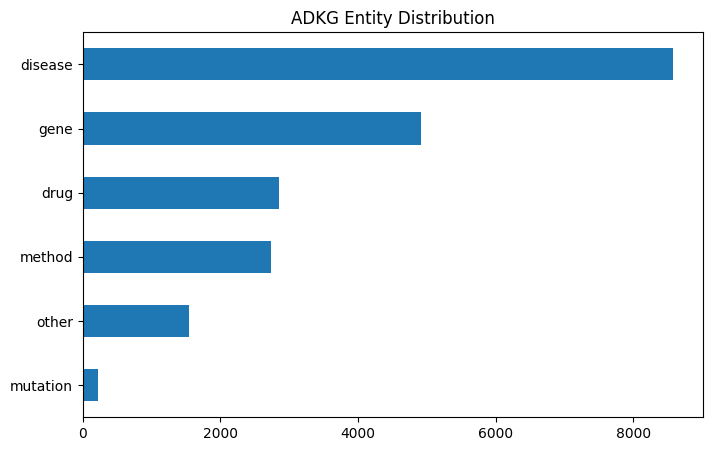

In [7]:
pd.Series(adkg_entities).sort_values().plot(kind="barh", figsize=(8,5))
plt.title("ADKG Entity Distribution")
plt.show()

## Dataset Summary Statistics
Basic statistics are generated to better understand the distribution of entities and relations in the biomedical corpora.

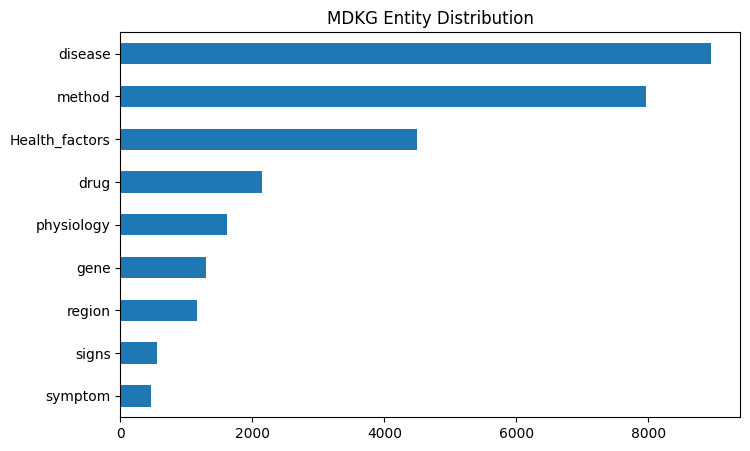

In [8]:
pd.Series(mdkg_entities).sort_values().plot(kind="barh", figsize=(8,5))
plt.title("MDKG Entity Distribution")
plt.show()

## Final Validation Results
The final outputs summarize whether the datasets are structurally valid and ready for downstream preprocessing and training.